# **Assignment 2: Problem 1 - Learning Word Embeddings From IIT Jodhpur Data**

*   Name: Shrusti Vipulbhai Jain
*   Roll No: M25CSE030

## Task 1: Dataset Preparation

### A. Collecting Textual Data

In [ ]:
# Importing necessary files

import requests
from bs4 import BeautifulSoup
import re

import numpy as np
import random
from collections import Counter

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# This stores all cleaned text sentences collected from different sources
all_clean_text = []

In [ ]:
# Cleaning Function for website pages data

def clean_website_text(text):
    """
    In this function, we clean and filter raw text extracted from different sources.
    Here, we remove extra spaces and unnecessary whitespace using regular expressions.
    Then, this filters out very short text fragments, to remove menu items, headings, or incomplete phrases.
    Further, removes sentences containing common navigation menu type words.
    If the text is considered useful, it is returned.
    Otherwise, None is returned to discard the text.
    """

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # remove very small sentences (menus, etc.)
    if len(text) < 40:
        return None

    # remove unwanted keywords (menu / navigation)
    unwanted_words = [
        "home", "contact", "admission", "faculty",
        "infrastructure", "office", "programs"
    ]

    # remove extra characters
    text = re.sub(r'[^a-zA-Z0-9.,()\- ]', '', text)

    # remove numbering patterns like a), 1.
    text = re.sub(r'\b[a-z]\)', '', text)
    text = re.sub(r'\b\d+\.', '', text)

    if any(word in text.lower() for word in unwanted_words):
        return None

    return text

In [ ]:
# Source 1: IIT Jodhpur official website pages
"""
In this step, a list of IIT Jodhpur web pages is defined.
These pages include information about the institute, departments, academic programs, and research activities.
The purpose of selecting multiple pages is to ensure that the collected text corpus contains diverse vocabulary
Hence, useful for training Word2Vec models and get better performance.
"""

# Defining IIT Jodhpur official website pages URLs to be used as source for corpus
iitj_website_urls = [
    "https://www.iitj.ac.in/main/en/iitj",
    "https://www.iitj.ac.in/main/en/introduction",
    "https://www.iitj.ac.in/main/en/vision-and-mission",
    "https://www.iitj.ac.in/main/en/history",
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://www.iitj.ac.in/computer-science-engineering/en/computer-science-and-engineering",
    "https://www.iitj.ac.in/bioscience-bioengineering",
    "https://www.iitj.ac.in/mathematics/",
    "https://www.iitj.ac.in/chemistry/en/chemistry",
    "https://www.iitj.ac.in/physics/"
]

In [ ]:
# Function for Web Scraping of IITJ website

def scrape_and_save_webpage(url, file_index):
    """
    In this, text is extracted from each IIT Jodhpur webpage and saved in separate text file.
    Here, first webpage is requested using requests library.
    Then, HTML content is parsed using BeautifulSoup.
    Also, unnecessary HTML sections are removed as they do not contain useful text.
    And, text is extracted from paragraph (<p>) and list (<li>) tags, since these usually contain meaningful content.
    Further, each extracted text is cleaned using the clean_text function and only valid cleaned text is added to the corpus list.
    So, structured and relevant textual data is collected from multiple web pages.
    """

    print("Web Scraping:", url)

    page_text = []

    try:
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        # remove unwanted HTML sections
        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()

        # extract text from paragraphs and lists
        for tag in soup.find_all(["p", "li"]):
            text = tag.get_text()
            cleaned_text = clean_website_text(text)

            if cleaned_text:
                page_text.append(cleaned_text)

    except Exception as e:
        print("Error in URL:", url)

    # Save each webpage into separate file
    filename = f"webpage_{file_index}.txt"

    with open(filename, "w", encoding="utf-8") as f:
        for line in page_text:
            f.write(line + "\n")

    return filename, page_text

In [ ]:
# Performing web scraping for all webpages listed earlier of IITJ website

webpage_files = []
all_clean_text = []

for i, url in enumerate(iitj_website_urls):
    file_name, page_text = scrape_and_save_webpage(url, i+1)

    webpage_files.append(file_name)

    # Add to global corpus
    all_clean_text.extend(page_text)

Web Scraping: https://www.iitj.ac.in/main/en/iitj
Web Scraping: https://www.iitj.ac.in/main/en/introduction
Web Scraping: https://www.iitj.ac.in/main/en/vision-and-mission
Web Scraping: https://www.iitj.ac.in/main/en/history
Web Scraping: https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology
Web Scraping: https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development
Web Scraping: https://www.iitj.ac.in/computer-science-engineering/en/computer-science-and-engineering
Web Scraping: https://www.iitj.ac.in/bioscience-bioengineering
Web Scraping: https://www.iitj.ac.in/mathematics/
Web Scraping: https://www.iitj.ac.in/chemistry/en/chemistry
Web Scraping: https://www.iitj.ac.in/physics/


In [ ]:
# Removing duplicates from the text to be used for corpus
all_clean_text = list(set(all_clean_text))

In [ ]:
# Source 2: Academic regulation documents

"""
In this step, text extracted from academic regulation PDF files is loaded.
Here, first open each text file containing extracted PDF content.
Then, read the file line by line.
Further, apply cleaning function and add valid cleaned text to the corpus list.
This ensures that formal academic language is included in the dataset, so improves quality of learned word embeddings.
"""

academic_docs = ["academic_1.txt", "academic_2.txt"]

for file in academic_docs:
    try:
        with open(file, "r", encoding="latin-1") as f:
            for line in f:
                line = clean_website_text(line)
                if line:
                    all_clean_text.append(line)
    except:
        print("Error reading:", file)

In [ ]:
# Source 3: Course syllabus

course_doc = "course_text.txt"

"""
In this step, manually collected course content is added to the corpus.
Here, each line is cleaned using the same cleaning function and added to the corpus.
So, now course-related content helps in including domain-specific technical vocabulary.
"""

try:
    with open(course_doc, "r", encoding="utf-8") as f:
        for line in f:
            line = clean_website_text(line)
            if line:
                all_clean_text.append(line)
except:
    print("Error reading course_text.txt")

In [ ]:
# Saving the final Corpus

"""
In this step, all collected text data is combined and saved into a file.
Also, duplicate entries are taken care of and cleaned corpus is written line by line into 'corpus.txt'.
This file obtained here is used as input for training Word2Vec models in later stages.
Also, the total number of collected sentences is printed for verification.
"""

all_clean_text = list(set(all_clean_text))

with open("corpus.txt", "w", encoding="utf-8") as f:
    for line in all_clean_text:
        f.write(line + "\n")

print("Raw corpus file is saved")
print("\nTotal sentences collected:", len(all_clean_text))

Raw corpus file is saved

Total sentences collected: 1589


### B. Preprocessing Collected Data

In [ ]:
# Function for Loading Corpus

def load_corpus(file_path):
    """
    In this function, corpus is read line by line.
    Also, empty lines are removed.
    It returns list of sentences from corpus.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # Remove newline characters
    lines = [line.strip() for line in lines if line.strip() != ""]

    return lines

In [ ]:
# Load raw corpus
raw_sentences = load_corpus("corpus.txt")

print("Total raw sentences in corpus:", len(raw_sentences))

Total raw sentences in corpus: 1589


In [ ]:
# Cleaning function for corpus data collected

def clean_text(sentence):
    """
    In this function, we clean raw text in the corpus.
    Here, we convert all text to lowercase form, so uniform representation obtained.
    Also, we remove extra spaces using regular expressions.
    Further, unwanted characters so keep alphabets only, which gives cleaner vocabulary.
    If the text is considered useful, then it is returned.
    """

    # Convert to lowercase
    sentence = sentence.lower()

    # Remove unwanted characters (keep only alphabets)
    sentence = re.sub(r'[^a-z\s]', '', sentence)

    # Remove extra spaces
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    return sentence

In [ ]:
# Preprocessing function for corpus

def preprocess_corpus(sentences):
    """
    In this function, we apply cleaning on entire corpus.
    Also, remove very short sentences after cleaning the corpus, so noisy data gets reduced.
    This returns sentences of clean corpus.
    """

    cleaned_sentences = []

    for sentence in sentences:
        clean_sentence = clean_text(sentence)

        # Remove very short sentences
        if len(clean_sentence.split()) < 4:
            continue

        cleaned_sentences.append(clean_sentence)

    return cleaned_sentences

In [ ]:
# Apply preprocessing
clean_sentences = preprocess_corpus(raw_sentences)

print("Total cleaned sentences for corpus:", len(clean_sentences))

Total cleaned sentences for corpus: 1564


In [ ]:
# Stopwords defined for corpus

def get_stopwords():
    """
    In this function, we returns basic set of English stopwords.
    This are very common words which do not carry strong semantic meaning.
    So, removing them helps improve Word2Vec model learning.
    """

    return set([
        "the", "and", "of", "to", "in", "a", "for", "is", "on", "that",
        "by", "this", "with", "as", "an", "are", "was", "were", "be",
        "from", "at", "or", "it", "which", "but", "has", "have", "had",
        "not", "will", "can", "may", "must", "should"
    ])

In [ ]:
# Removal of Stopwords from the corpus

def remove_stopwords(sentences):
    """
    In this function, we removes stopwords from each sentence in corpus.
    This improves quality of embeddings by keeping only meaningful words.
    Also, returns filtered sentences which will be added to clean_sentences.
    """
    stopwords = get_stopwords()
    filtered_sentences = []

    for sentence in sentences:
        words = sentence.split()
        filtered_words = [w for w in words if w not in stopwords]

        if len(filtered_words) > 2:  # keep meaningful sentences
            filtered_sentences.append(" ".join(filtered_words))

    return filtered_sentences

In [ ]:
# Apply Stopword Removal
clean_sentences = remove_stopwords(clean_sentences)

In [ ]:
# Function for tokenization of corpus

def tokenize_corpus(sentences):
    """
    In this function, we convert sentences into list of word tokens.
    Here, we split sentences into words to prepare data for Word2Vec.
    So, token list is created.
    This returns tokenized sentences of corpus.
    """

    tokenized = [sentence.split() for sentence in sentences]
    return tokenized

In [ ]:
# Tokenizing preprocessed corpus
tokenized_sentences = tokenize_corpus(clean_sentences)

# Flattening tokens
all_tokens = [word for sentence in tokenized_sentences for word in sentence]

print("Sample tokens:", all_tokens[:20])

Sample tokens: ['apply', 'appropriate', 'theories', 'design', 'principles', 'frameworks', 'protocols', 'develop', 'ai', 'ds', 'based', 'weighted', 'voting', 'games', 'vector', 'weighted', 'voting', 'games', 'network', 'flow']


In [ ]:
# Save tokenized corpus

def save_tokenized_corpus(tokenized_sentences, file_path):
    """
    In this function, we save tokenized corpus into a file.
    Here, each sentence is written as space-separated tokens.
    """

    with open(file_path, "w", encoding="utf-8") as f:
        for sentence in tokenized_sentences:
            f.write(" ".join(sentence) + "\n")


save_tokenized_corpus(tokenized_sentences, "tokenized_corpus.txt")

print("Tokenized corpus file is saved")

Tokenized corpus file is saved


### C. Computation of Dataset Statistics

In [ ]:
# Compute dataset statistics

def compute_statistics(sentences, tokens, webpage_files, academic_docs, course_doc):
    """
    In this function, statistics of dataset or corpus for this problem are computed.
    Here, Documents includes webpages, academic regulation pdfs and course syllabus.
    Also, total no. of tokens calculated for dataset.
    Further, Vocabulary size calculated for dataset.
    """

    vocab = set(tokens)

    # Count documents
    num_web_docs = len(webpage_files)
    num_academic_docs = len(academic_docs)
    num_course_docs = 1

    total_documents = num_web_docs + num_academic_docs + num_course_docs

    stats = {
        "num_documents": total_documents,
        "web_documents": num_web_docs,
        "academic_documents": num_academic_docs,
        "course_documents": num_course_docs,
        "total_tokens": len(tokens),
        "vocab_size": len(vocab)
    }

    return stats

In [ ]:
# Computing statistics of dataset and printing them

stats = compute_statistics(
    clean_sentences,
    all_tokens,
    webpage_files,
    academic_docs,
    course_doc
)

print("\n--- DATASET STATISTICS ---")
print("Total Documents:", stats["num_documents"])
print("Web Documents:", stats["web_documents"])
print("Academic Documents:", stats["academic_documents"])
print("Course Documents:", stats["course_documents"])
print("Total Tokens:", stats["total_tokens"])
print("Vocabulary Size:", stats["vocab_size"])


--- DATASET STATISTICS ---
Total Documents: 14
Web Documents: 11
Academic Documents: 2
Course Documents: 1
Total Tokens: 15858
Vocabulary Size: 3745


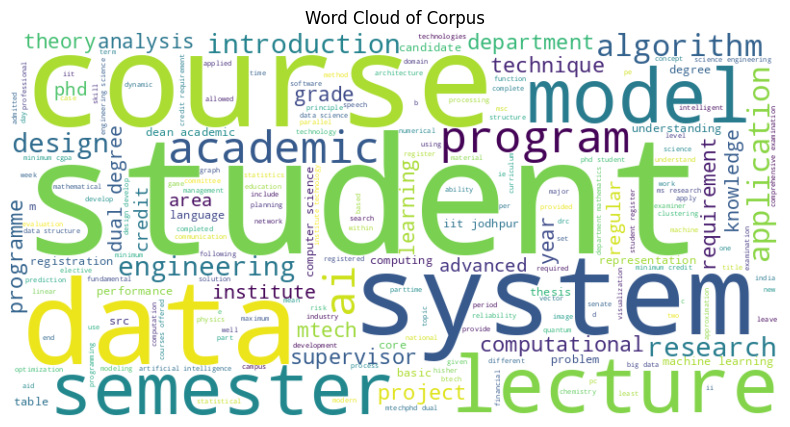

In [ ]:
# Display word cloud for dataset

def generate_wordcloud(tokens):
    """
    In this function, word cloud plot shown.
    This shows most frequent words in larger size than others.
    So, we can observe the nature of dataset using this plot.
    """

    text = " ".join(tokens)

    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud of Corpus")
    plt.show()


generate_wordcloud(all_tokens)

## Task 2: Word2Vec Model Training

### A. Generate Training Data for Word2Vec Models

In [ ]:
def build_vocab(tokenized_sentences):
    """
    In this function, we build vocabulary for Word2Vec models.
    Here, we convert words to numbers, because this is required for ML models.
    Also, creates mapping both ways (i.e. word to number and number to word).
    """

    vocab = set()
    for sentence in tokenized_sentences:
        for word in sentence:
            vocab.add(word)

    word2idx = {word: i for i, word in enumerate(vocab)}
    idx2word = {i: word for word, i in word2idx.items()}

    return word2idx, idx2word, len(vocab)

In [ ]:
# Training data for CBOW generated

def generate_cbow_data(tokenized_sentences, word2idx, window_size):
    """
    In this function, we generate (context, target) pairs for CBOW.
    Because, CBOW predicts center word from context given.
    """

    data = []

    for sentence in tokenized_sentences:
        for i, target_word in enumerate(sentence):

            context = []

            for j in range(i - window_size, i + window_size + 1):
                if j != i and 0 <= j < len(sentence):
                    context.append(word2idx[sentence[j]])

            if context:
                data.append((context, word2idx[target_word]))

    return data

In [ ]:
# Training data for Skip-gram generated

def generate_skipgram_data(tokenized_sentences, word2idx, window_size):
    """
    In this function, we generate (target, context) pairs for Skip-gram.
    Because, Skip-gram predicts context from center word given.
    """

    data = []

    for sentence in tokenized_sentences:
        for i, target_word in enumerate(sentence):

            target = word2idx[target_word]

            for j in range(i - window_size, i + window_size + 1):
                if j != i and 0 <= j < len(sentence):
                    context = word2idx[sentence[j]]
                    data.append((target, context))

    return data

In [ ]:
# Initialization of Embeddings

def initialize_embeddings(vocab_size, embedding_dim):
    """
    In this function, we initialize embedding matrices for models.
    Here, W1 is the input embedding and W2 is the output embedding.
    Also, we have done random initialization because we want the model to learn.
    """

    W1 = np.random.uniform(-0.5, 0.5, (vocab_size, embedding_dim))
    W2 = np.random.uniform(-0.5, 0.5, (embedding_dim, vocab_size))

    return W1, W2

In [ ]:
# Function to compute Softmax

def softmax(x):
    """
    In this function, we compute softmax.
    This is done so that the values generated for each word can be considered as probability.
    """

    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

### B. Word2Vec Model: Continuous Bag ofWords (CBOW)

In [ ]:
def train_cbow(data, vocab_size, embedding_dim, epochs=15, lr=0.01):
    """
    In this function, CBOW Word2Vec model training is done.
    First, average of context vectors is taken.
    And, based on above center word is predicted.
    Also, update weights using gradient for above.
    """

    W1, W2 = initialize_embeddings(vocab_size, embedding_dim)

    for epoch in range(epochs):
        loss = 0

        for context, target in data:

            # Average context embeddings
            h = np.mean(W1[context], axis=0)

            # Output layer
            u = np.dot(h, W2)
            y_pred = softmax(u)

            # Compute loss
            loss -= np.log(y_pred[target] + 1e-9)

            # Backprop
            e = y_pred
            e[target] -= 1

            dW2 = np.outer(h, e)
            dW1 = np.dot(W2, e) / len(context)

            # Update
            W2 -= lr * dW2
            for idx in context:
                W1[idx] -= lr * dW1

        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    return W1

### C. Word2Vec Model: Skip-gram with Negative Sampling

In [ ]:
def negative_sampling(vocab_size, positive_idx, k):
    """
    In this function, we generate 'k' no. of negative samples.
    This are to be used in the WOrd2Vec Skip-gram model training.
    """

    negatives = []
    while len(negatives) < k:
        sample = random.randint(0, vocab_size - 1)
        if sample != positive_idx:
            negatives.append(sample)

    return negatives

In [ ]:
def train_skipgram(data, vocab_size, embedding_dim, neg_samples, epochs=15, lr=0.01):
    """
    In this function, Skip-gram Word2Vec model training is done.
    First, we predict context words using given center word.
    Then, use negative samples instead of full softmax.
    So, here faster training occurs.
    """

    W1, W2 = initialize_embeddings(vocab_size, embedding_dim)

    for epoch in range(epochs):
        loss = 0

        for target, context in data:

            h = W1[target]

            # Positive sample
            score = np.dot(h, W2[:, context])
            prob = 1 / (1 + np.exp(-score))
            loss -= np.log(prob + 1e-9)

            grad = prob - 1
            W2[:, context] -= lr * grad * h
            W1[target] -= lr * grad * W2[:, context]

            # Negative samples
            negatives = negative_sampling(vocab_size, context, neg_samples)

            for neg in negatives:
                score = np.dot(h, W2[:, neg])
                prob = 1 / (1 + np.exp(-score))
                loss -= np.log(1 - prob + 1e-9)

                grad = prob
                W2[:, neg] -= lr * grad * h
                W1[target] -= lr * grad * W2[:, neg]

        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    return W1

### D. Experimenting with Model Parameters: CBOW and Skip-Gram

Experiment on different values of Embedding dimension, Context window size and Number of negative samples are performed. Values considered are as follows:

*   Embedding Dimension: 100, 300
*   Context Window Size: 3, 5
*   Number of Negative Sample: 5, 10


CBOW experiments include:
*   Embedding Dimension: 100, Context Window Size: 3
*   Embedding Dimension: 300, Context Window Size: 5

Skip-Gram experiments include:
*   Embedding Dimension: 100, Context Window Size: 3, Number of Negative Sample: 5
*   Embedding Dimension: 300, Context Window Size: 5, Number of Negative Sample: 10

In [ ]:
# Building vocabulary for training Word2Vec models

word2idx, idx2word, vocab_size = build_vocab(tokenized_sentences)
print("Vocabulary size:", vocab_size)

Vocabulary size: 3745


In [ ]:
def run_experiments(tokenized_sentences, word2idx, vocab_size):
    """
    In this function, we perform multiple Word2Vec experiments (CBOW + Skip-gram)
    with different values of Embedding dimension, Context window size and Number of negative samples.
    Also, this stores embeddings in dictionary.
    """

    results = {}

    # CBOW Experiments
    print("\nRunning CBOW (dim=100, window=3)")
    cbow_data = generate_cbow_data(tokenized_sentences, word2idx, window_size=3)
    emb_cbow_100 = train_cbow(cbow_data, vocab_size, embedding_dim=100)
    results["CBOW_100"] = emb_cbow_100

    print("\nRunning CBOW (dim=300, window=5)")
    cbow_data = generate_cbow_data(tokenized_sentences, word2idx, window_size=5)
    emb_cbow_300 = train_cbow(cbow_data, vocab_size, embedding_dim=300)
    results["CBOW_300"] = emb_cbow_300

    # Skip-gram Experiments
    print("\nRunning Skip-gram (dim=100, window=3, neg=5)")
    sg_data = generate_skipgram_data(tokenized_sentences, word2idx, window_size=3)
    emb_sg_100 = train_skipgram(sg_data, vocab_size, embedding_dim=100, neg_samples=5)
    results["SG_100"] = emb_sg_100

    print("\nRunning Skip-gram (dim=300, window=5, neg=10)")
    sg_data = generate_skipgram_data(tokenized_sentences, word2idx, window_size=5)
    emb_sg_300 = train_skipgram(sg_data, vocab_size, embedding_dim=300, neg_samples=10)
    results["SG_300"] = emb_sg_300

    return results

In [ ]:
# Performing Experiments on all Word2Vec models
# Also, saves results in dictionary, where each key represents an experiment

embeddings_dict = run_experiments(tokenized_sentences, word2idx, vocab_size)
print("\nAll experiments completed.")


Running CBOW (dim=100, window=3)
Epoch 1, Loss: 131358.0151
Epoch 2, Loss: 129908.5265
Epoch 3, Loss: 128371.5238
Epoch 4, Loss: 126635.1174
Epoch 5, Loss: 124615.9765
Epoch 6, Loss: 122287.5672
Epoch 7, Loss: 119742.3542
Epoch 8, Loss: 117190.6129
Epoch 9, Loss: 114715.7282
Epoch 10, Loss: 112335.0010
Epoch 11, Loss: 110053.7595
Epoch 12, Loss: 107880.4591
Epoch 13, Loss: 105814.3594
Epoch 14, Loss: 103837.3404
Epoch 15, Loss: 101931.0808

Running CBOW (dim=300, window=5)
Epoch 1, Loss: 132237.9658
Epoch 2, Loss: 128914.3714
Epoch 3, Loss: 125519.7872
Epoch 4, Loss: 121928.2198
Epoch 5, Loss: 118218.7822
Epoch 6, Loss: 114568.9732
Epoch 7, Loss: 111091.9014
Epoch 8, Loss: 107812.5932
Epoch 9, Loss: 104725.6602
Epoch 10, Loss: 101809.1520
Epoch 11, Loss: 99038.1057
Epoch 12, Loss: 96397.5201
Epoch 13, Loss: 93876.5609
Epoch 14, Loss: 91464.2268
Epoch 15, Loss: 89149.5849

Running Skip-gram (dim=100, window=3, neg=5)
Epoch 1, Loss: 348042.8837
Epoch 2, Loss: 330096.4743
Epoch 3, Loss: 

### E. Gensim Word2Vec

In [ ]:
# Install gensim
!pip install gensim

# Import library
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.7 MB/s eta 0:00:00


In [ ]:
# Using already tokenized corpus which is list of list of words

print("Sample tokenized sentence:", tokenized_sentences[0])

Sample tokenized sentence: ['apply', 'appropriate', 'theories', 'design', 'principles', 'frameworks', 'protocols', 'develop', 'ai', 'ds', 'based']


In [ ]:
# Training CBOW model using Gensim
# Here, we ignore rare words to avoid noisy data learning.
# Also, sg = 0 kept which indicates CBOW to be used.

gensim_cbow = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=3,
    min_count=2,
    sg=0,
    workers=4,
    epochs=10
)

print("Gensim CBOW training completed")

Gensim CBOW training completed


In [ ]:
# Train Skip-gram model using Gensim
# Here, we ignore rare words to avoid noisy data learning.
# Also, sg = 1 kept which indicates skip-gram to be used.

gensim_sg = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=3,
    min_count=2,
    sg=1,
    workers=4,
    epochs=10
)

print("Gensim Skip-gram training completed")

Gensim Skip-gram training completed


## Task 3: Semantic Analysis

In [ ]:
# Dictionary of all trained models
models = {
    "CBOW_100": embeddings_dict["CBOW_100"],
    "CBOW_300": embeddings_dict["CBOW_300"],
    "SG_100": embeddings_dict["SG_100"],
    "SG_300": embeddings_dict["SG_300"]
}

### A. Top 5 Nearest Neighbors

In [ ]:
def cosine_similarity(vec1, vec2):
    """
    In this function, we compute cosine similarity between two vectors.
    Here, when value is closer to 1, it means vectors are more similar.
    This is the basic idea of Word2Vec evaluation.
    """

    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    return dot_product / (norm1 * norm2 + 1e-9)

In [ ]:
def get_nearest_neighbors(word, word2idx, idx2word, embedding_matrix, top_k=5):
    """
    In this function, we find top-k nearest words using cosine similarity.
    So, finds similar words based on vector closeness.
    It is used to show semantic grouping.
    This returns top-k similar words for given word.
    """

    if word not in word2idx:
        print(f"{word} not in vocabulary")
        return []

    target_vec = embedding_matrix[word2idx[word]]

    similarities = []

    for idx in range(len(idx2word)):
        other_word = idx2word[idx]

        if other_word == word:
            continue

        other_vec = embedding_matrix[idx]
        sim = cosine_similarity(target_vec, other_vec)

        similarities.append((other_word, sim))

    # sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]

In [ ]:
def evaluate_neighbors(models, words, word2idx, idx2word):
    """
    In this function, we compute nearest neighbors for given words
    across multiple models and show results for comparison.
    """

    for model_name, emb in models.items():
        print("\n" + "="*50)
        print(f"MODEL: {model_name}")
        print("="*50)

        for word in words:
            print(f"\nNearest neighbors for '{word}':")

            if word not in word2idx:
                print("Word not in vocabulary")
                continue

            neighbors = get_nearest_neighbors(
                word,
                word2idx,
                idx2word,
                emb
            )

            for w, score in neighbors:
                print(w, round(score, 4))

In [ ]:
# Obtain top-k neighbours for given words using all models

words_to_check = ["research", "student", "phd", "examination"]
evaluate_neighbors(models, words_to_check, word2idx, idx2word)


MODEL: CBOW_100

Nearest neighbors for 'research':
regular 0.4944
projects 0.4265
registered 0.4082
any 0.3929
requirements 0.3905

Nearest neighbors for 'student':
students 0.5603
grade 0.4603
semester 0.4517
academic 0.4469
credits 0.4224

Nearest neighbors for 'phd':
mtech 0.581
allowed 0.5156
regular 0.4678
credit 0.4257
courses 0.4237

Nearest neighbors for 'examination':
allowed 0.4133
semester 0.3584
moe 0.3165
sgd 0.3145
per 0.3125

MODEL: CBOW_300

Nearest neighbors for 'research':
credits 0.2618
student 0.2491
academics 0.246
supervisor 0.244
regular 0.2421

Nearest neighbors for 'student':
students 0.4254
program 0.3288
credits 0.3003
phd 0.2935
academic 0.2929

Nearest neighbors for 'phd':
mtech 0.3114
student 0.2935
academic 0.2704
program 0.2674
semester 0.2563

Nearest neighbors for 'examination':
student 0.2431
hisher 0.2254
requirements 0.2168
while 0.2069
s 0.1998

MODEL: SG_100

Nearest neighbors for 'research':
average 0.5589
every 0.52
ms 0.5176
objection 0.4908
i

### B. Analogy Experiments

In [ ]:
def analogy(word_a, word_b, word_c, word2idx, idx2word, embedding_matrix, top_k=5):
    """
    In this function, we solve analogy like: A : B :: C : ?
    Here, it uses vector arithmetic like: B - A + C
    So, finds closest word to resulting vector.
    This is used to test semantic relationships.
    It returns top-k similar words for given analogy.
    """

    for word in [word_a, word_b, word_c]:
        if word not in word2idx:
            print(f"{word} not in vocabulary")
            return []

    vec_a = embedding_matrix[word2idx[word_a]]
    vec_b = embedding_matrix[word2idx[word_b]]
    vec_c = embedding_matrix[word2idx[word_c]]

    # analogy vector
    target_vec = vec_b - vec_a + vec_c

    similarities = []

    for idx in range(len(idx2word)):
        word = idx2word[idx]

        if word in [word_a, word_b, word_c]:
            continue

        vec = embedding_matrix[idx]
        sim = cosine_similarity(target_vec, vec)

        similarities.append((word, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]

In [ ]:
def evaluate_analogies(models, analogies, word2idx, idx2word):
    """
    In this function, we perform analogy tasks across all models.
    This helps to compare semantic understanding.
    """

    for model_name, emb in models.items():
        print("\n" + "="*50)
        print(f"MODEL: {model_name}")
        print("="*50)

        for a, b, c in analogies:
            print(f"\nAnalogy: {a} : {b} :: {c} : ?")

            if a not in word2idx or b not in word2idx or c not in word2idx:
                print("One of the words not in vocabulary")
                continue

            results = analogy(a, b, c, word2idx, idx2word, emb)

            for word, score in results:
                print(word, round(score, 4))

In [ ]:
# Obtain analogies for various models

analogies = [
    ("undergraduate", "btech", "postgraduate"),
    ("research", "paper", "course"),
    ("examination", "grade", "course"),
]

evaluate_analogies(models, analogies, word2idx, idx2word)


MODEL: CBOW_100

Analogy: undergraduate : btech :: postgraduate : ?
credit 0.3836
cases 0.3269
manipulation 0.3231
rather 0.3204
clauses 0.3146

Analogy: research : paper :: course : ?
ie 0.4188
title 0.3792
computational 0.371
mous 0.3474
targeted 0.3159

Analogy: examination : grade :: course : ?
deep 0.4372
penn 0.4149
respective 0.4015
thesis 0.3971
if 0.3931

MODEL: CBOW_300

Analogy: undergraduate : btech :: postgraduate : ?
bank 0.2348
connectomics 0.1951
students 0.1915
ng 0.1876
humanities 0.1841

Analogy: research : paper :: course : ?
modelling 0.2193
estimating 0.1936
prescriptive 0.1916
possible 0.1912
bfs 0.1903

Analogy: examination : grade :: course : ?
semester 0.2594
per 0.2518
courses 0.2101
provided 0.2095
first 0.208

MODEL: SG_100

Analogy: undergraduate : btech :: postgraduate : ?
table 0.5725
pursue 0.5268
programmes 0.5245
double 0.5101
credit 0.5087

Analogy: research : paper :: course : ?
distribution 0.4987
study 0.4594
during 0.4569
concept 0.4546
instruct

### C. 300-dimensional Embedding Vector of Word in Vocabulary

In [ ]:
def get_embedding(word, model_name, embeddings, word2idx):
    """
    In this function, we obtain embedding for a word.
    Here, input are word, word's index and which hyperparameter based model's embedding required is given.
    Also, this returns embedding vector for a given word.
    """

    if word not in word2idx:
        print("Word not found")
        return

    emb = embeddings[model_name]
    vector = emb[word2idx[word]]

    print(f"\n{word} ({model_name}) -")
    print(",".join([str(round(x, 4)) for x in vector]))

In [ ]:
# Get embedding vector for given word using CBOW 300
get_embedding("research", "CBOW_300", embeddings_dict, word2idx)


research (CBOW_300) -
-0.4813,0.393,0.0601,0.0774,0.2094,0.5229,0.5492,0.3204,0.1404,-0.2824,0.6064,0.7352,-0.4889,-0.3533,-0.2047,0.04,0.4432,-0.3985,-0.4356,-0.323,0.2597,-0.7003,0.2921,-0.2708,0.4126,0.1325,0.4188,-0.3242,0.7839,-0.6993,-0.3818,-0.4381,-0.0316,0.213,-0.3185,-0.3364,0.206,-0.5987,-0.222,0.2099,-0.298,0.9815,-0.2527,0.2342,-0.0878,-0.2391,-0.0789,-0.5883,-0.2529,0.4287,-0.0399,-0.3261,-0.4595,0.3583,0.634,0.2067,-0.34,-0.705,0.6264,-0.3624,0.3021,-0.1206,0.2388,-0.3176,-0.0028,-0.8079,-0.4856,0.5538,0.1095,0.1513,0.3163,-0.4148,0.0012,0.2034,0.287,-0.2043,0.0401,0.2051,-0.07,-0.2136,-0.6084,-0.3814,-0.3627,-0.1513,-0.3822,0.1295,0.1301,-0.289,-0.3257,0.0256,0.4711,0.0653,0.1392,0.0079,0.7558,0.0304,-0.0214,0.3404,0.2782,-0.1382,-0.5257,0.2301,-0.5677,0.4951,-0.1275,0.1113,-0.3664,-0.1304,0.6865,0.7356,-0.047,0.0302,0.7412,0.2568,-0.385,-0.225,0.1871,0.0076,-0.3815,0.2679,-0.1251,0.4509,-0.6099,-0.36,-0.0925,-0.0515,0.3407,-0.2707,0.3832,0.2592,-0.4363,-0.1777,0.0744,

In [ ]:
# Get embedding vector for given word using Skip-gram 300
get_embedding("research", "SG_300", embeddings_dict, word2idx)


research (SG_300) -
-0.4167,-0.4671,0.0632,0.3502,-0.2378,1.1875,-0.1674,-0.1721,0.6989,-0.355,-0.6224,0.2285,-0.2186,0.4945,-0.5815,0.0536,0.0811,-0.7974,0.1907,-0.151,0.5495,0.2605,-0.4784,0.1259,-0.5914,0.6092,-0.1956,0.0605,-0.2407,-0.0782,0.2429,-0.7879,0.289,-0.1352,-0.1332,0.8186,-0.4678,-0.3092,0.76,0.9007,-0.2617,0.5005,0.044,0.2622,0.1004,0.924,-0.0859,0.0375,0.6248,0.3561,0.2928,-0.9784,0.2882,-0.2839,0.2045,-0.3275,0.2508,-0.4381,0.8202,-0.2691,-0.6422,0.0626,-0.6131,0.3292,0.2394,0.5537,0.1214,-0.301,0.4649,0.6176,-0.3836,-0.0751,0.2153,0.2578,-1.0922,0.3083,-0.2555,0.2404,-0.2697,-0.0716,0.0748,-0.2652,-0.43,-0.5678,0.1819,-0.469,-0.4322,-0.4049,-0.2886,0.2548,0.2854,-0.1679,-0.235,0.2462,0.1513,0.4259,-0.2794,0.1091,0.2729,-0.7092,0.6488,0.5563,0.3295,-0.4153,0.5884,-0.4147,-0.0641,-0.1066,0.624,-0.2869,-0.2323,0.3648,-0.2954,0.3014,0.6632,-0.3809,-0.0634,-0.3349,0.2794,-0.6233,0.7402,0.6576,-0.3481,-0.9408,-0.2345,0.8041,0.3723,-0.0618,-0.4609,0.0618,-0.7193,0.8127,-0.

### D. Top-10 Words (Frequency-wise)

In [ ]:
def top_k_words(tokens, k=10):
    """
    In this function, we take tokens and number of frequent words to be found.
    Here, we count word frequency in corpus.
    So, it shows dataset distribution.
    This returns top-k frequent words in corpus.
    """

    # Use Counter to get the frequencies
    counts = Counter(tokens)
    top_words = counts.most_common(k)

    print(f"\nTop {k} words:")

    for word, freq in top_words:
        print(f"{word}: {freq}")

In [ ]:
def plot_top_k_words(tokens, k=10):
    """
    In this function, we take tokens and number of frequent words to be found.
    Here, we count word frequency in corpus.
    So, it shows dataset distribution.
    """

    # Get frequencies
    counts = Counter(tokens)
    top_words = counts.most_common(k)

    # Unpack words and their counts
    words, frequencies = zip(*top_words)

    # Create the bar graph
    plt.figure(figsize=(10, 6))
    plt.bar(words, frequencies, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title(f'Top {k} Most Frequent Words')
    plt.xticks(rotation=45) # Rotates labels so they don't overlap
    plt.show()

In [ ]:
# Get Top-10 words (frequency-wise) in corpus
top_k_words(all_tokens, 10)


Top 10 words:
data: 180
student: 171
course: 130
students: 115
science: 99
engineering: 94
systems: 89
program: 86
learning: 84
research: 80


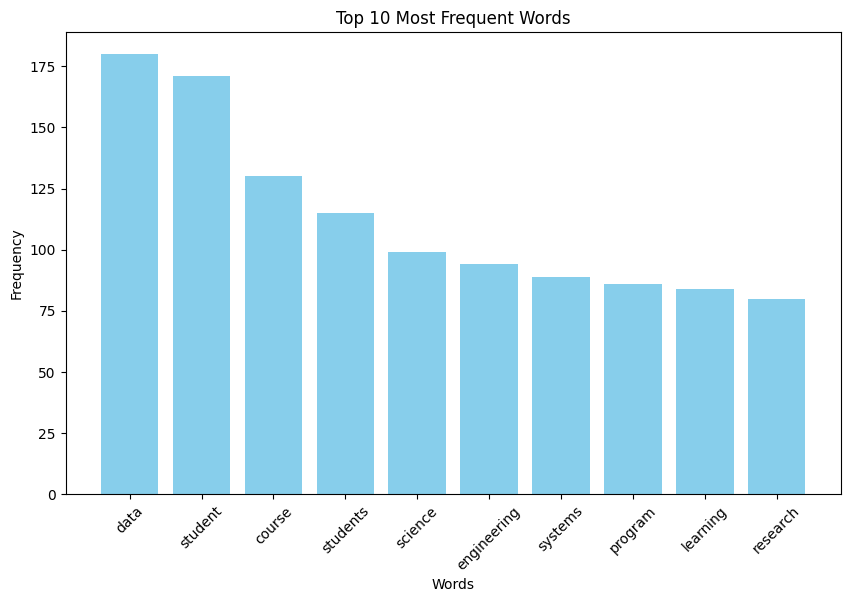

In [ ]:
# Plotting bar graph for top k words
plot_top_k_words(all_tokens, k=10)

### E. Comparison with Gensim Word2Vec Model

In [ ]:
def gensim_neighbors(model, words):
    """
    In this function, we obtain nearest neighbors using gensim model.
    This uses in-built cosine similarity computation.
    """

    for word in words:
        print(f"\nNearest neighbors for '{word}':")

        if word not in model.wv:
            print("Word not in vocabulary")
            continue

        results = model.wv.most_similar(word, topn=5)

        for w, score in results:
            print(w, round(score, 4))

In [ ]:
# Obtain top-k neighbours for given words using Gensim models

words_to_check = ["research", "student", "phd", "examination"]

print("\n" + "="*50)
print("Gensim CBOW Top-k neighbours")
print("="*50)
gensim_neighbors(gensim_cbow, words_to_check)

print("\n" + "="*50)
print("Gensim Skip-gram Top-k neighbours")
print("="*50)
gensim_neighbors(gensim_sg, words_to_check)


Gensim CBOW Top-k neighbours

Nearest neighbors for 'research':
data 0.9993
course 0.9992
student 0.9992
supervisor 0.9992
lectures 0.9991

Nearest neighbors for 'student':
students 0.9994
semester 0.9994
course 0.9993
academic 0.9993
shall 0.9993

Nearest neighbors for 'phd':
program 0.9991
academic 0.9988
students 0.9987
degree 0.9987
student 0.9987

Nearest neighbors for 'examination':
course 0.9988
student 0.9988
data 0.9987
research 0.9987
students 0.9987

Gensim Skip-gram Top-k neighbours

Nearest neighbors for 'research':
hisher 0.9966
complete 0.9965
candidate 0.9963
mentioned 0.9961
grades 0.9961

Nearest neighbors for 'student':
register 0.995
regular 0.9935
phd 0.993
requirements 0.9923
credits 0.9915

Nearest neighbors for 'phd':
mtech 0.996
student 0.993
requirements 0.9916
regular 0.9912
register 0.9908

Nearest neighbors for 'examination':
who 0.9947
comprehensive 0.9947
same 0.9946
makeup 0.9945
hisher 0.9945


In [ ]:
def gensim_analogy(model, a, b, c):
    """
    In this function, we perform analogy tasks using gensim.
    This helps to compare semantic understanding.
    """

    try:
        results = model.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=5
        )

        for w, score in results:
            print(w, round(score, 4))

    except:
        print("Words not in vocabulary")

In [ ]:
# Obtain analogies for Gensim models

analogies = [
    ("undergraduate", "btech", "postgraduate"),
    ("research", "paper", "course"),
    ("examination", "grade", "course"),
]

print("\n" + "="*50)
print("Gensim CBOW Analogies")
print("="*50)
for a, b, c in analogies:
    print(f"\n{a}:{b} :: {c}:?")
    gensim_analogy(gensim_cbow, a, b, c)

print("\n" + "="*50)
print("Gensim Skip-gram Analogies")
print("="*50)
for a, b, c in analogies:
    print(f"\n{a}:{b} :: {c}:?")
    gensim_analogy(gensim_sg, a, b, c)


Gensim CBOW Analogies

undergraduate:btech :: postgraduate:?
number 0.9366
including 0.9354
admitted 0.9347
been 0.9344
where 0.9343

research:paper :: course:?
conducted 0.9375
intelligent 0.9373
equations 0.9365
development 0.9356
human 0.9353

examination:grade :: course:?
models 0.9978
systems 0.9977
knowledge 0.9976
analysis 0.9976
student 0.9976

Gensim Skip-gram Analogies

undergraduate:btech :: postgraduate:?
makeup 0.9941
programmes 0.9936
completing 0.9934
regulations 0.9934
duration 0.9934

research:paper :: course:?
leave 0.9884
any 0.9883
categories 0.9882
selfstudy 0.9879
fellowship 0.9877

examination:grade :: course:?
awarded 0.9857
semester 0.9849
during 0.9841
after 0.984
completion 0.9835


In [ ]:
def gensim_embedding(model, word):
    """
    In this function, we find embedding vector of a word.
    """

    if word not in model.wv:
        print("Word not found")
        return

    vector = model.wv[word]

    print(word, "-", ",".join([str(round(x, 4)) for x in vector]))

In [ ]:
# Get embedding vector for given word using Gensim Skip-gram model
gensim_embedding(gensim_sg, "research")

research - -0.1965,0.243,-0.0207,0.0542,-0.0034,-0.2953,0.0685,0.3884,-0.1584,-0.1715,-0.1526,-0.2676,-0.0441,0.015,0.0457,-0.1801,0.0881,-0.2655,0.0657,-0.3617,0.1481,0.1501,0.0643,-0.1389,-0.1186,0.0277,-0.2257,-0.1601,-0.1199,0.0629,0.2625,0.0598,-0.1006,-0.0576,-0.0332,0.2847,-0.0406,-0.1698,0.0207,-0.3478,0.1045,-0.1724,0.0685,0.0602,0.1021,-0.0154,-0.1622,-0.0341,0.075,0.0517,0.1263,-0.1671,-0.1234,0.0823,-0.151,0.1502,0.1792,0.0613,-0.3178,0.0407,0.0248,0.1696,-0.1036,-0.0415,-0.2951,0.1513,0.0156,0.0683,-0.2094,0.2495,-0.0842,0.0418,0.2359,-0.1763,0.1562,0.0213,-0.0163,-0.0772,-0.1669,0.1159,-0.1205,-0.0551,-0.1666,0.2781,0.1207,-0.0388,-0.0417,0.2989,0.3056,0.0939,0.1953,0.089,0.012,0.0543,0.3351,0.1435,0.0935,-0.2282,0.0647,-0.0129


In [ ]:
# Get embedding vector for given word using Gensim CBOW model
gensim_embedding(gensim_cbow, "research")

research - -0.2273,0.316,-0.026,0.0368,0.0563,-0.4654,0.0808,0.6002,-0.253,-0.1599,-0.2193,-0.4399,-0.0441,0.0974,0.0992,-0.2584,0.0695,-0.3737,0.0332,-0.5207,0.243,0.235,0.1005,-0.2021,-0.1712,-0.0238,-0.3128,-0.2436,-0.2681,0.0509,0.5039,0.0027,-0.0087,-0.125,-0.0532,0.4632,-0.058,-0.2669,-0.1078,-0.6188,0.0752,-0.2955,-0.0138,0.0501,0.1879,-0.0963,-0.2543,-0.064,0.0925,0.1638,0.1203,-0.3254,-0.1599,0.0342,-0.2515,0.2362,0.2257,0.0338,-0.447,0.0508,0.0927,0.151,-0.1176,-0.0119,-0.4154,0.3046,0.0525,0.1981,-0.3555,0.3447,-0.1396,0.1281,0.3838,-0.1562,0.3109,0.1414,-0.011,-0.1273,-0.311,0.1441,-0.1005,-0.0415,-0.2805,0.4604,0.0449,-0.0027,-0.0924,0.3643,0.4128,0.1462,0.402,0.1825,0.0553,0.1268,0.494,0.2872,0.1238,-0.3269,0.1165,-0.0521


## Task 4: Visualization

In [ ]:
def select_words_for_visualization(vocab, num_words=50):
    """
    In this function, we select words for visualization.
    Here, we pick first N words from vocabulary.
    """

    selected_words = list(vocab)[:num_words]
    return selected_words

In [ ]:
def get_word_vectors(words, word2idx, embedding_matrix):
    """
    In this function, we extract embedding vectors for selected words.
    Here, we convert words to vectors for model.
    Also, skip missing words and returns only valid ones.
    """

    vectors = []
    valid_words = []

    for word in words:
        if word in word2idx:
            vectors.append(embedding_matrix[word2idx[word]])
            valid_words.append(word)

    return np.array(vectors), valid_words

In [ ]:
# PCA

def reduce_dimensions_pca(vectors, n_components=2):
    """
    In this function, we reduce dimensions using PCA.
    This converts 100 or 300-dimensions to 2-dimensions.
    Also, keeps maximum variance, while being fast and stable.
    So, further plotting can be done to visulize clusters formed.
    """

    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(vectors)

    return reduced

In [ ]:
# t-SNE

def reduce_dimensions_tsne(vectors, n_components=2):
    """
    In this function, we reduce dimensions using t-SNE.
    This preserves local structure.
    Also, gives better clusters than PCA, but is somewhat slower.
    So, further plotting can be done to visulize clusters formed.
    """

    perplexity = min(30, len(vectors) - 1)

    tsne = TSNE(n_components=n_components,  perplexity=perplexity, random_state=42)
    reduced = tsne.fit_transform(vectors)

    return reduced

In [ ]:
def plot_embeddings_2d(reduced_vectors, words, title="Embedding Visualization"):
    """
    In this function, we plot 2D embeddings with word labels.
    """

    plt.figure(figsize=(10, 8))

    for i, word in enumerate(words):
        x, y = reduced_vectors[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, word, fontsize=9)

    plt.title(title)
    plt.grid()
    plt.show()

### A. Visualization for CBOW Model

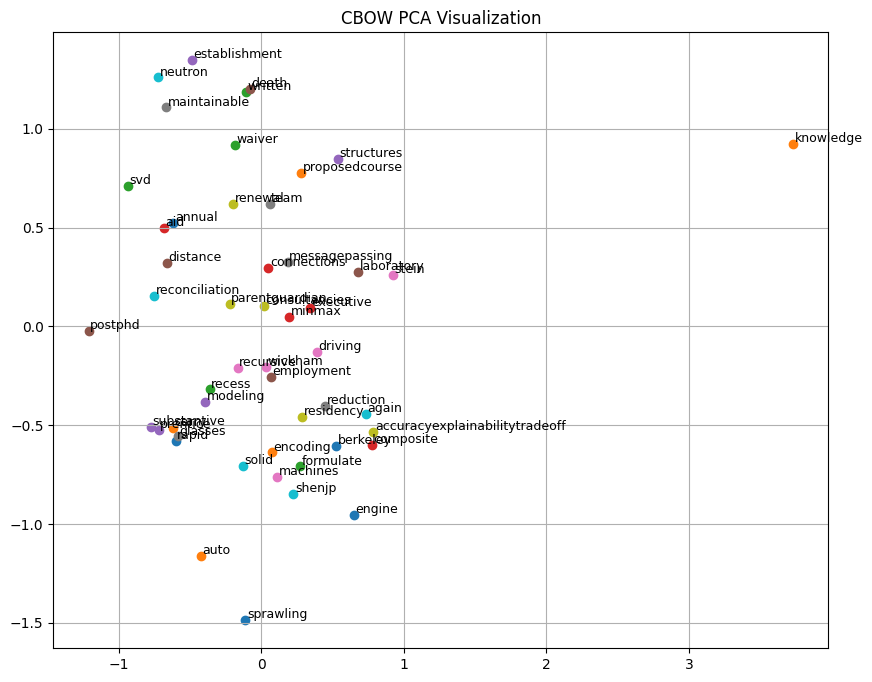

In [ ]:
# PCA visualization for CBOW embeddings

selected_words = select_words_for_visualization(word2idx.keys(), 50)

vectors_cbow, words_cbow = get_word_vectors(
    selected_words,
    word2idx,
    embeddings_dict["CBOW_100"]
)

reduced_cbow = reduce_dimensions_pca(vectors_cbow)

plot_embeddings_2d(reduced_cbow, words_cbow, "CBOW PCA Visualization")

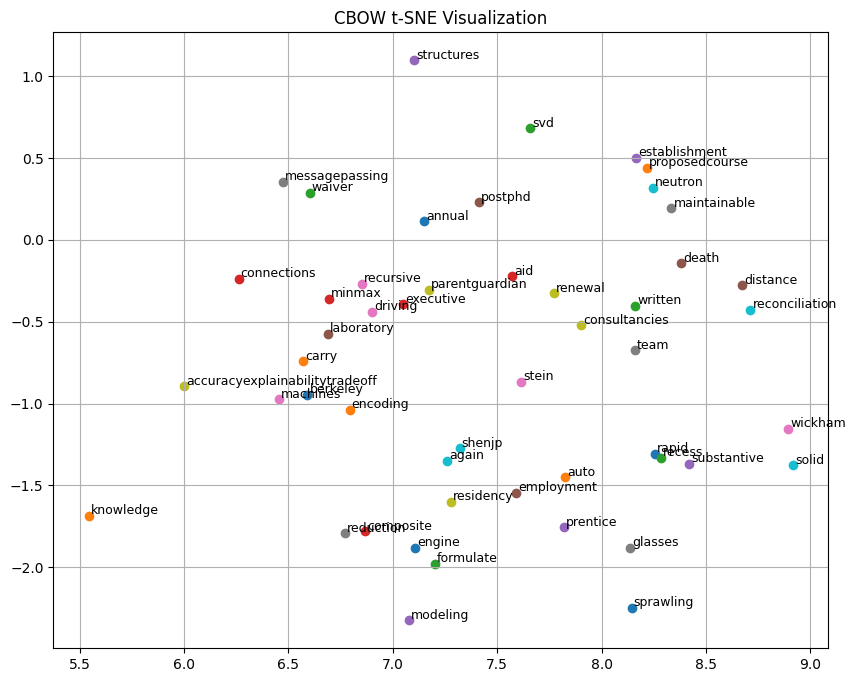

In [ ]:
# t-SNE visualization for CBOW embeddings

reduced_tsne_cbow = reduce_dimensions_tsne(vectors_cbow)

plot_embeddings_2d(
    reduced_tsne_cbow,
    words_cbow,
    "CBOW t-SNE Visualization"
)

### B. Visualization for Skip-gram Model

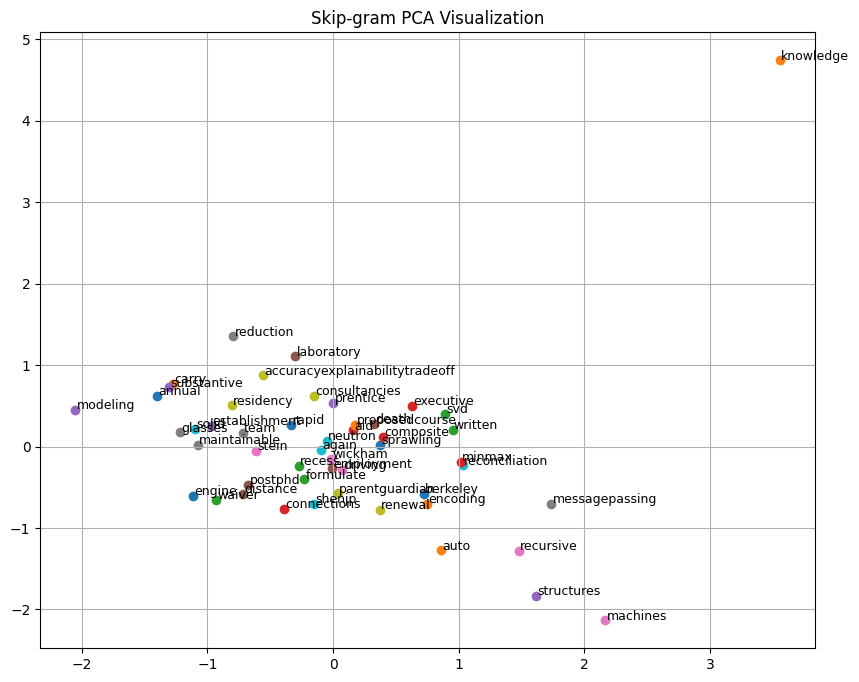

In [ ]:
# PCA visualization for Skip-gram embeddings

vectors_sg, words_sg = get_word_vectors(
    selected_words,
    word2idx,
    embeddings_dict["SG_300"]
)

reduced_sg = reduce_dimensions_pca(vectors_sg)

plot_embeddings_2d(reduced_sg, words_sg, "Skip-gram PCA Visualization")

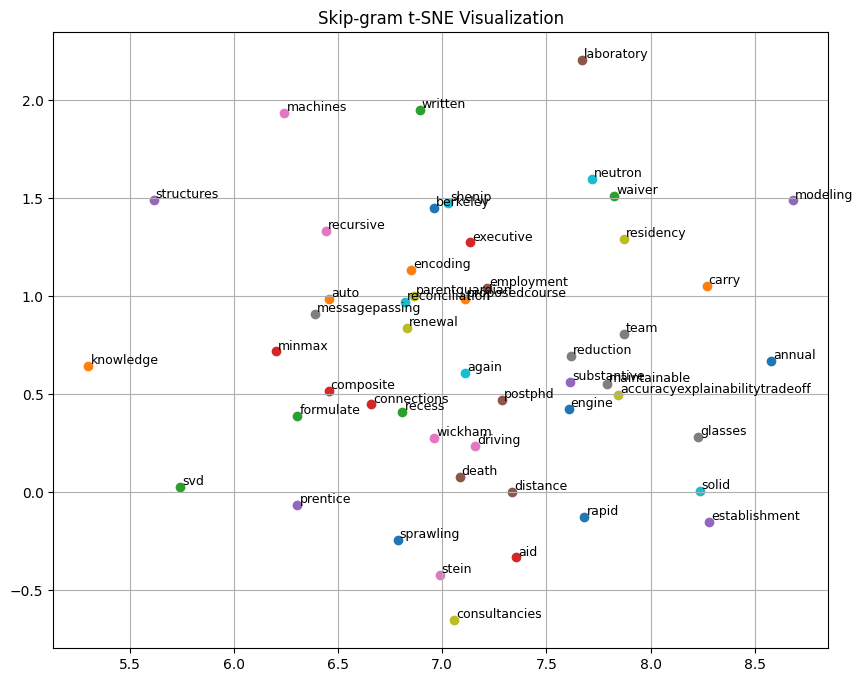

In [ ]:
# t-SNE visualization for Skip-gram embeddings

reduced_tsne = reduce_dimensions_tsne(vectors_sg)

plot_embeddings_2d(reduced_tsne, words_sg, "Skip-gram t-SNE Visualization")

### C. Visualization for Gensim Models

In [ ]:
def get_gensim_word_vectors(words, model):
    """
    In this function, we extract word vectors from a trained gensim model.
    It takes a list of words.
    Further, returns corresponding vectors and filtered words (only those present in vocabulary).
    """

    vectors = []
    valid_words = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            valid_words.append(word)

    return vectors, valid_words

In [ ]:
# Selected same words for fair comparison
selected_words = select_words_for_visualization(word2idx.keys(), 50)

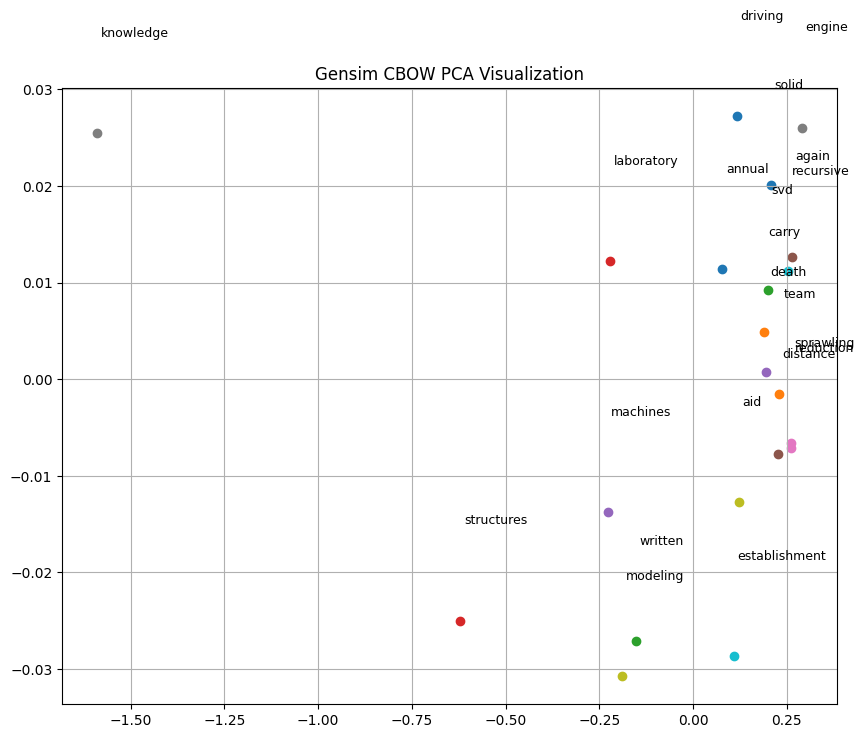

In [ ]:
# PCA visualization for Gensim CBOW embeddings

vectors_gensim_cbow, words_gensim_cbow = get_gensim_word_vectors(
    selected_words,
    gensim_cbow
)

reduced_gensim_cbow = reduce_dimensions_pca(vectors_gensim_cbow)

plot_embeddings_2d(
    reduced_gensim_cbow,
    words_gensim_cbow,
    "Gensim CBOW PCA Visualization"
)

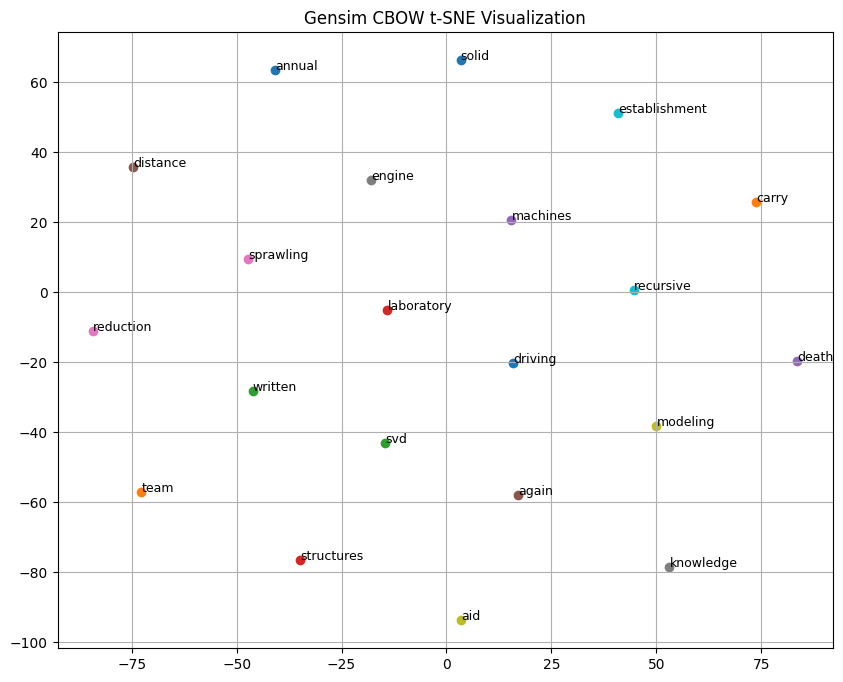

In [ ]:
# t-SNE visualization for Gensim CBOW embeddings

# Convert to numpy array
vectors_gensim_cbow = np.array(vectors_gensim_cbow)

# t-SNE visualization
reduced_tsne_gensim_cbow = reduce_dimensions_tsne(vectors_gensim_cbow)

plot_embeddings_2d(
    reduced_tsne_gensim_cbow,
    words_gensim_cbow,
    "Gensim CBOW t-SNE Visualization"
)

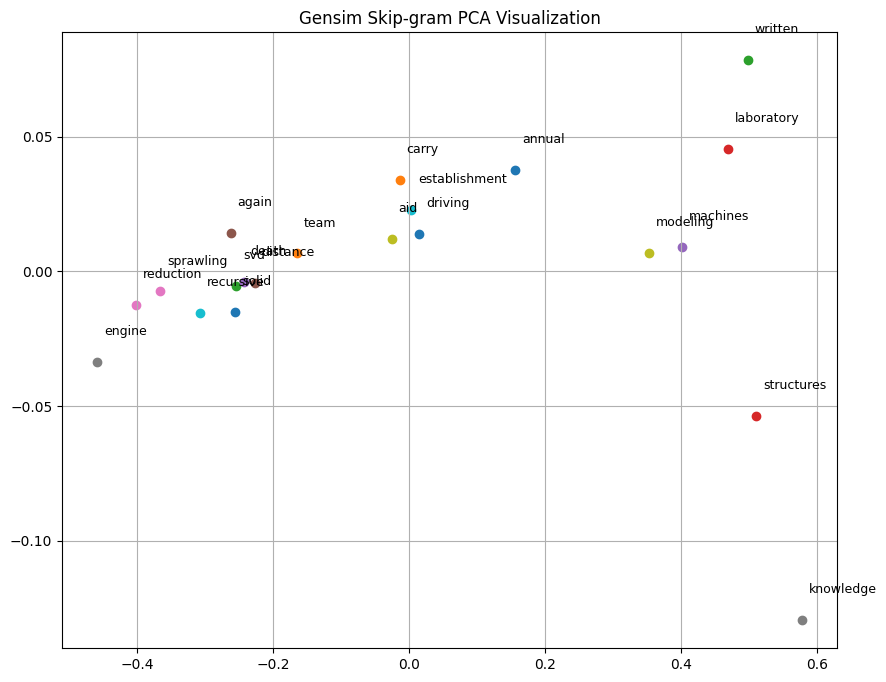

In [ ]:
# PCA visualization for Gensim Skip-gram embeddings

vectors_gensim_sg, words_gensim_sg = get_gensim_word_vectors(
    selected_words,
    gensim_sg
)

reduced_gensim_sg = reduce_dimensions_pca(vectors_gensim_sg)

plot_embeddings_2d(
    reduced_gensim_sg,
    words_gensim_sg,
    "Gensim Skip-gram PCA Visualization"
)

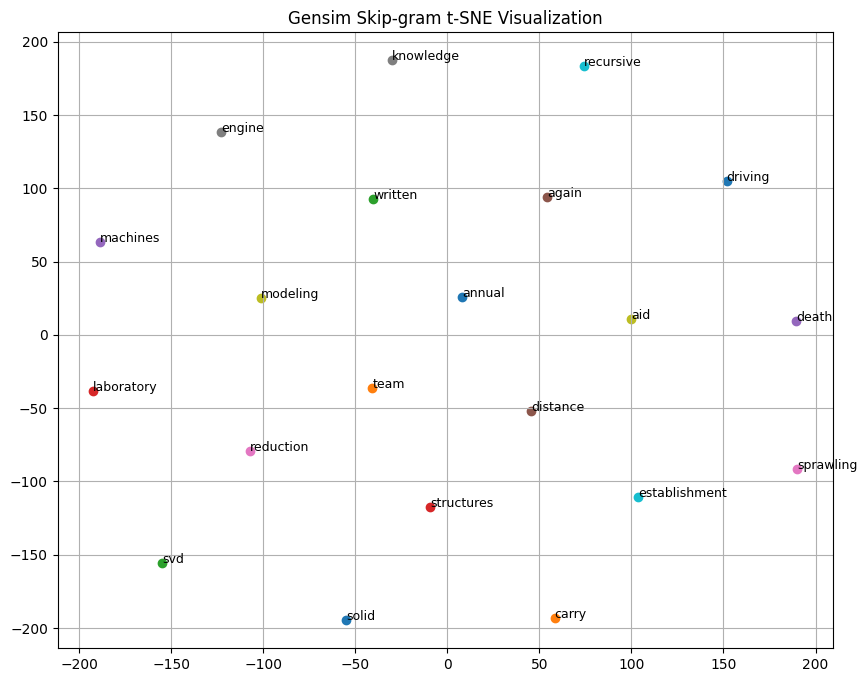

In [ ]:
# t-SNE visualization for Gensim Skip-gram embeddings

# Convert to numpy array
vectors_gensim_sg = np.array(vectors_gensim_sg)

# t-SNE visualization
reduced_tsne_gensim_sg = reduce_dimensions_tsne(vectors_gensim_sg)

plot_embeddings_2d(
    reduced_tsne_gensim_sg,
    words_gensim_sg,
    "Gensim Skip-gram t-SNE Visualization"
)